# Семинар: Базовый RAG

В рамках ноутбука познакомимся с RAG-системами: их устройством, модификациями, и когда вообще в них возникает необходимость.

In [1]:
!pip install -q \
    transformers>=4.40.0 \
    sentence-transformers>=2.6.0 \
    tokenizers>=0.19.0 \
    langchain>=0.2.0 \
    langchain-community>=0.2.0 \
    langchain-huggingface>=0.0.3 \
    langchain-qdrant>=0.1.0 \
    qdrant-client>=1.9.0 \
    huggingface-hub>=0.23.0 \
    datasets>=3.0.0

# Дополнительные пакеты для RAG
!pip install -q \
    rapidfuzz \
    tqdm \
    pandas \
    matplotlib \
    numpy


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.3 MB/s eta 0:00:00


In [ ]:
#!pip install -U datasets==3.6.0 huggingface_hub fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 765.1/765.1 kB 36.9 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.20.1
    Uninstalling huggingface_hub-1.20.1:
      Successfully uninstalled huggingface_hub-1.20.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


## 1. Загрузка и подготовка данных

Во-первых, определимся, с какими данными будем иметь сегодня дело.

Будем работать с датасетом на основе телеграм канала, который я ещё заранее спарсила:

In [2]:
import pandas as pd

df = pd.read_csv('gonzo_dump.csv')
df.head(5)

,Unnamed: 0,id,date,text,word_count
0,0,4058,2025-09-24T22:40:11+00:00,Что-то интересное:\n\nHappy to release Meta Co...,245
1,1,4057,2025-09-23T11:44:54+00:00,Что почитать в дороге,4
2,2,4055,2025-09-22T19:18:08+00:00,Когда же уже R2 наконец?!\n\nDeepSeek-V3.1 → D...,33
3,3,4053,2025-09-22T10:49:48+00:00,"Мы уже писали про варианты JEPA, например, JEP...",42
4,4,4040,2025-09-21T22:40:06+00:00,* **Самодистилляция:** Ещё более удивительно...,232


In [3]:
df.tail(5)

,Unnamed: 0,id,date,text,word_count
825,825,2052,2023-11-05T14:57:04+00:00,"The engine powering Grok is Grok-1, our fronti...",140
826,826,2050,2023-11-04T11:06:51+00:00,Когда сгенерил книгу через ChatGPT...,5
827,827,2038,2023-11-03T20:10:57+00:00,"Для ViT и JFT-300M эксперименты дорогие, это w...",435
828,828,2037,2023-11-03T20:10:56+00:00,**🪆Matryoshka Representation Learning**\n__Adi...,507
829,829,2035,2023-11-02T18:40:52+00:00,"""Applied ML"", an interesting case :)\n\nhttps:...",7


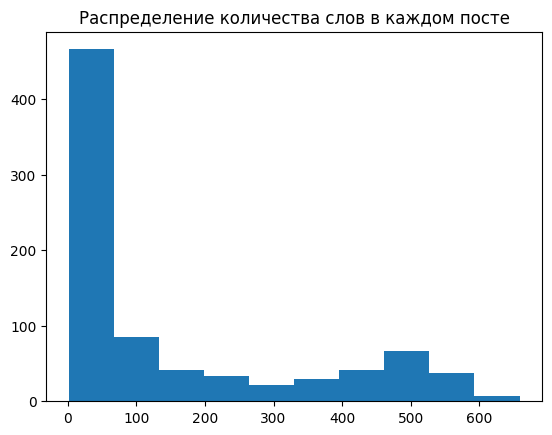

In [4]:
import matplotlib.pyplot as plt

df['word_count'] = df['text'].fillna('').str.split().str.len()

plt.hist(df['word_count'].values)
plt.title("Распределение количества слов в каждом посте");

Попробуем задать вопрос по нашим данным, не используя корректные контексты, в опоре на которые мы могли бы сгенерировать ответы (но не будем).

In [5]:
longest = df[df['word_count'] > 400].sample(5, random_state=42)['text'].values

for i, text in enumerate(longest):
    print(f"Пост номер {i + 1}: {text}")
    print("==========================")

Пост номер 1: Когда я в 2018-м делал свой обзор железа для глубокого обучения (https://moocaholic.medium.com/hardware-for-deep-learning-part-3-gpu-8906c1644664), стандартом в этой области был FP32, по ним топовые карты были до 20 TFLOPS. Тогда уже появлялся FP16 и тензорные ядра, с ними выходило под 130 TFLOPS. А теперь вот 3 петафлопса в одной топовой настольной карте. Но теперь на одной карте никто и не обучает… Для всех реальных обучений нужны гигантские кластера. И кроме компьюта надо ещё много памяти, в игровые карты её почти не ставят. Сейчас рекорд, кажется, это 32 гига в 5090? Были вроде ещё какие-то Quadro RTX 8000, где даже до 48 было, но то экзотика и уже неигровое. 

С игровыми видюхами тут много не сделаешь. Ну сделаешь, можно конечно собрать дешёвый аналог DGX, но всё это субоптимально. NVIDIA долго старалась разделить эти два рынка, и вот сейчас, кажется, они естественным образом к этому разделению пришли.

AMD конечно интересны со своей серией MI, в топовой модели MI325

Теперь подгрузим ещё и данные из, т.н. "золотого набора" -- некоторое количество пар вопрос-контекст, на котором мы будем считать "попадания". В моём случае "контекст" в том числе является и ответом, в вашем же случае ответ может отличаться от контекста в пользу большей естественности (это не так важно)

In [6]:
test_df = pd.read_excel("golden_mock.xlsx")
test_df.head(5)

,question,text
0,"Почему авторы считают, что попытка сохранить в...",Попытка запихнуть весь контекст в скрытое сост...
1,Как устроен механизм Log-Linear Attention и за...,Токены разбиваются на корзинки с экспоненциаль...
2,Как показал себя Log-Linear Attention по сравн...,На синтетике Log-Linear модификация значительн...
3,В чем заключается основная идея сетей Колмогор...,Авторы предлагают альтернативы классическим мн...
4,Как связаны теоремы Цыбенко и Колмогорова-Арно...,Классические MLP опираются на Универсальную те...


In [7]:
test_df['question'][1]

'Как устроен механизм Log-Linear Attention и за счет чего он достигает сложности `O(L log L)`?'

In [9]:
test_df['text'][2]

'На синтетике Log-Linear модификация значительно улучшает качество DeltaNet на MQAR (достать несколько элементов из контекста)... Log-Linear дает небольшой прирост поверх DeltaNet и Mamba-2. По скорости инференса на длинных контекстах Log-Linear Mamba-2 медленнее Mamba-2 (в ~2 раза на 64k/128k токенах), но быстрее Attention. На Needle-in-Haystack в бенче, где нужно достать один токен Log-Linear хорош, в multi-key/multi-value задачах Log-Linear лучше линейных бейзлайнов, но хуже Attention. На LongBench где-то дает прирост, а где-то не дает.'

## 2. Простой RAG

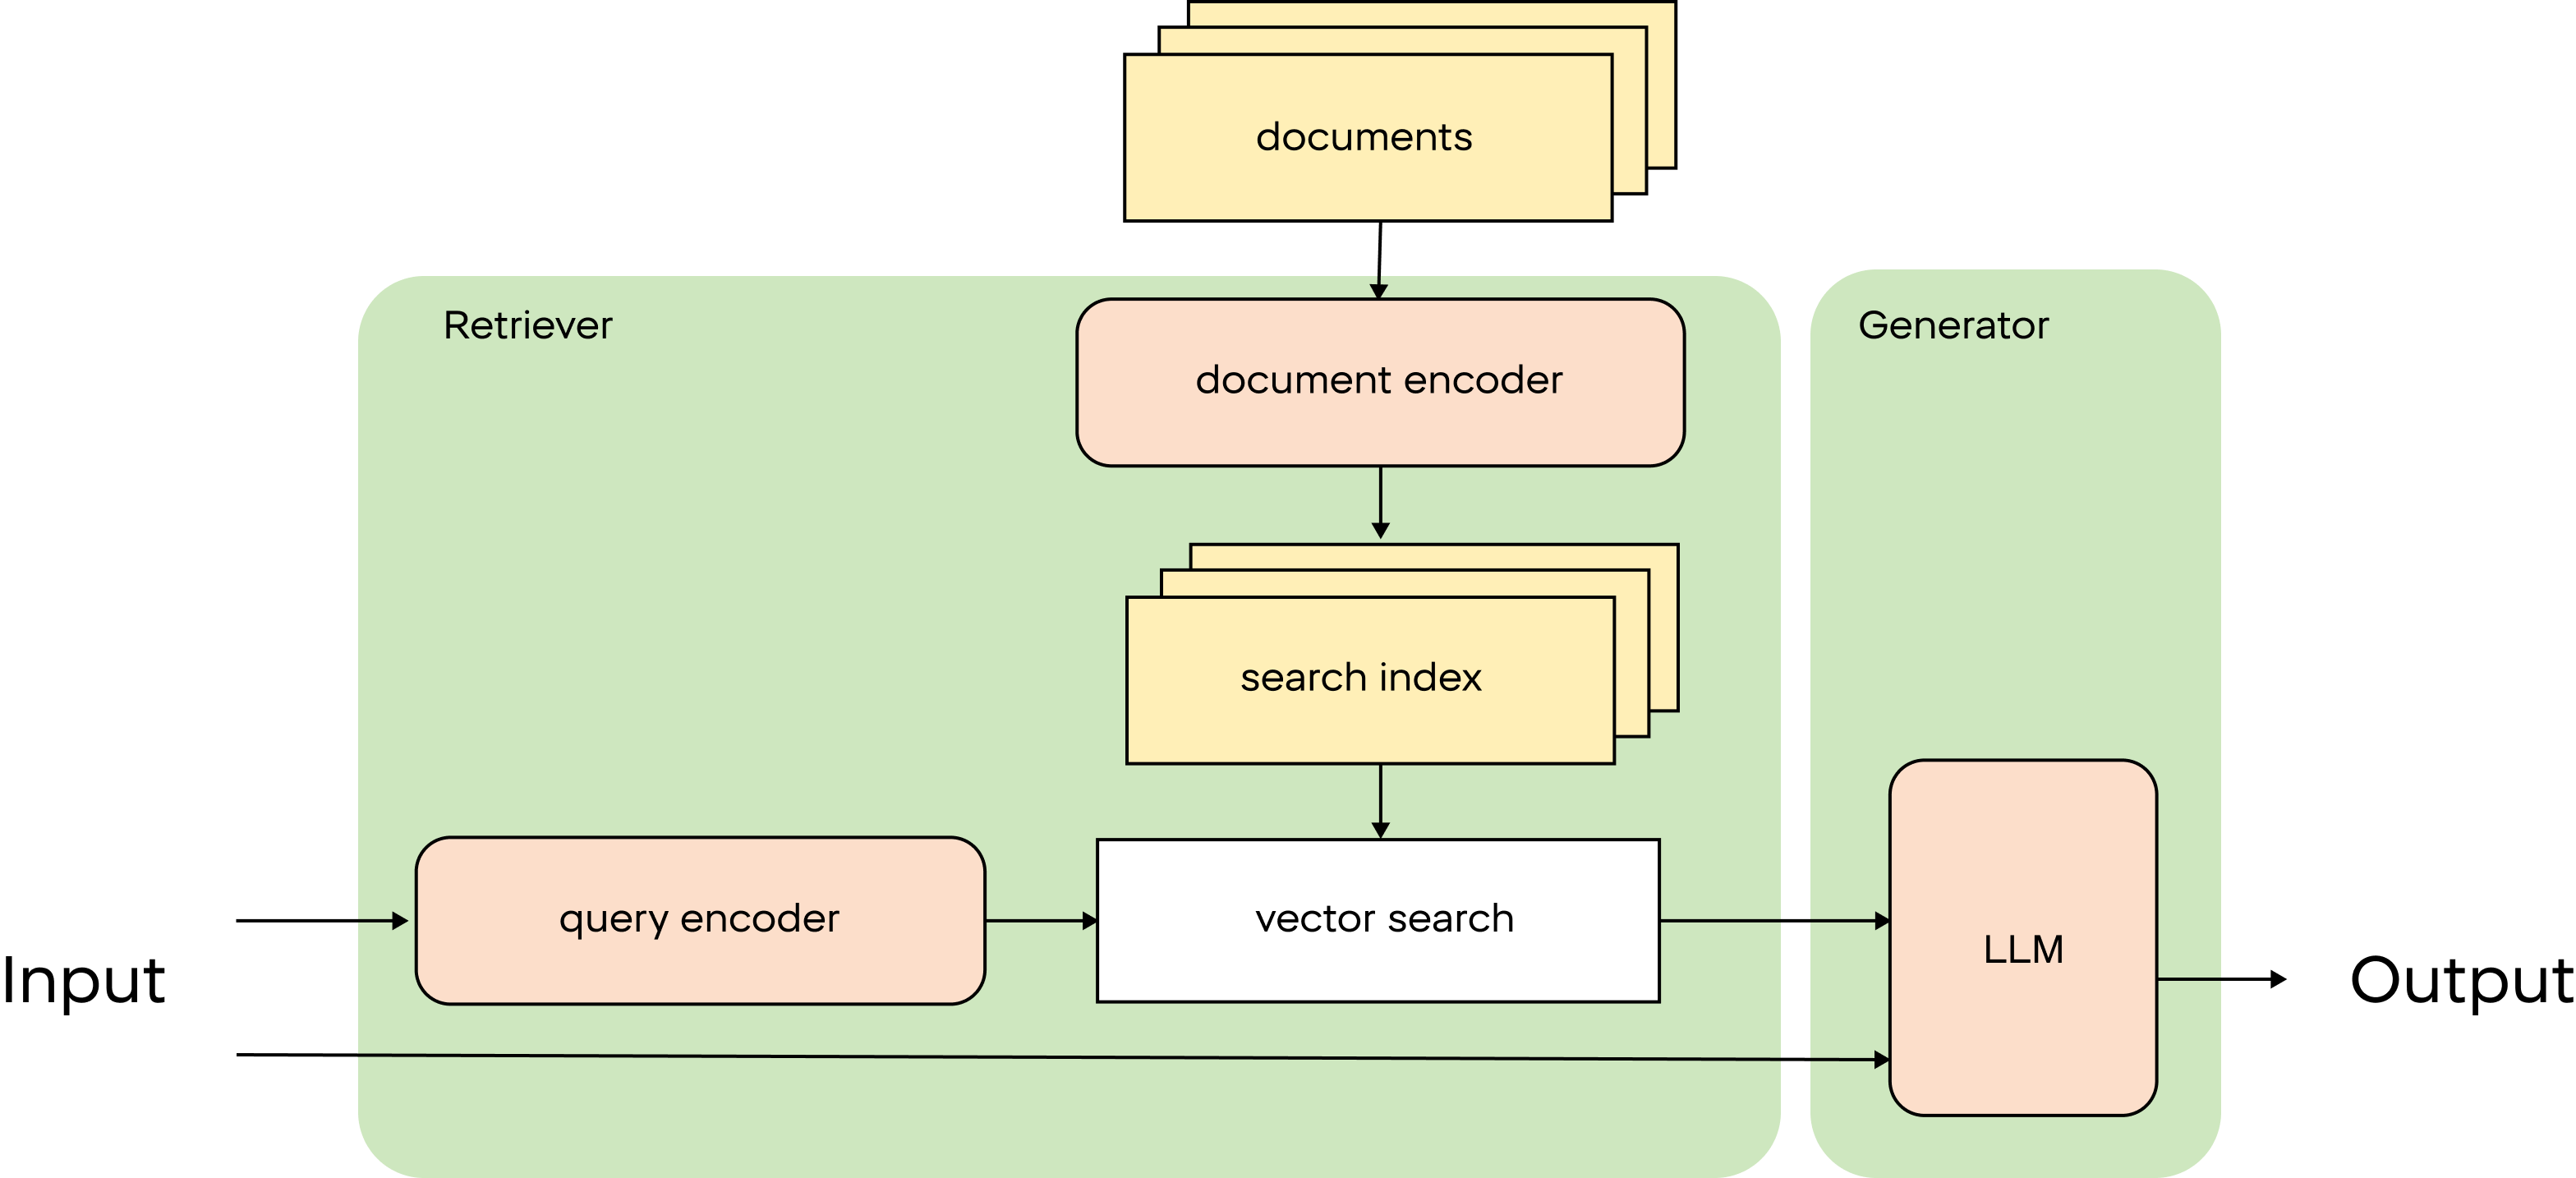

Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks, https://arxiv.org/pdf/2005.11401.pdf

In [ ]:
# ! pip install qdrant_client

In [ ]:
# !pip install langchain_huggingface langchain-qdrant langchain_text_splitters

In [ ]:
# !pip install transformers>=4.36.0 sentence-transformers>=2.3.0

### 2.1. Определение данных

In [10]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import PromptTemplate
from langchain_core.documents import Document

In [11]:
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ])

In [ ]:
# symsearch

"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['question'],
        metadata={
            "title": row['id'],
            "text": row['text']
            }
        )
        for i, row in df.iterrows()
    ])

document.metadata['text']
"""

'\ndoc_list = RecursiveCharacterTextSplitter().split_documents([\n    Document(\n        page_content=row[\'question\'],\n        metadata={\n            "title": row[\'id\'],\n            "text": row[\'text\']\n            }\n        )\n        for i, row in df.iterrows()\n    ])\n\ndocument.metadata[\'text\']\n'

In [ ]:
"""
question_1 -> question_generated(text_1)

question_1 -> text_1
question_1 -> text_2

documents[text_1, text_2]

"""

"""
question_1 -> question_generated(text_1)

question_1 -> text_1
question_2 -> text_1

documents[question_1, question_2]

"""

'\nquestion_1 -> question_generated(text_1)\n\nquestion_1 -> text_1\nquestion_1 -> text_2\n\ndocuments[text_1, text_2]\n\n'

In [12]:
df.iloc[0]['text']

"Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https://ai.meta.com/resources/models-and-libraries/cwm

In [13]:
doc_list[0]

Document(metadata={'title': 4058}, page_content="Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https:

In [ ]:
doc_list[0].page_content

"Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https://ai.meta.com/resources/models-and-libraries/cwm

In [ ]:
doc_list[0].metadata

{'title': 4058}

### 2.2. Определение эмбеддингов

Для кодирования документов и запросов воспользуемся моделью **`BAAI/bge-m3`** — симметричной мультиязычной моделью, не требующей специальных префиксов для кодирования запросов. Подробнее: [huggingface.co/BAAI/bge-m3](https://huggingface.co/BAAI/bge-m3).

In [14]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

cuda


In [15]:
# symetric model
embed_model_name = "BAAI/bge-m3"
embed_model_kwargs = {'device': device}
embed_encode_kwargs = {'normalize_embeddings': True}
query_encode_kwargs = {}

# asymetric model
"""
embed_model_name = "intfloat/multilingual-e5-large"
embed_model_kwargs = {'device': device}
encode_kwargs = {"prompt": "passage: "} # prompts
query_encode_kwargs = {"prompt": "query: "} # prompts
"""

embeddings = HuggingFaceEmbeddings(
    model_name=embed_model_name,
    model_kwargs=embed_model_kwargs,
    encode_kwargs=embed_encode_kwargs,
    query_encode_kwargs=query_encode_kwargs,
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

**⭐ Задание:** Попробуй заменить `BAAI/bge-m3` на другую модель из [MTEB Russian Leaderboard](https://huggingface.co/spaces/mteb/leaderboard?language=rus). Как изменятся метрики P@k и NDCG@k в разделе 2.4?

### 2.3. Определение векторной БД

In [16]:

qdrant = QdrantVectorStore.from_documents(
            doc_list,
            embeddings,
            location=":memory:",
            collection_name="documents",
)

qdrant_retriever = qdrant.as_retriever(verbose=True)

In [17]:
qdrant_retriever.invoke("Как быть, если в промптах для LLM содержится нерелевантная информация?")

[Document(metadata={'title': 2100, '_id': '45178810668f4183a51db91682a8df21', '_collection_name': 'documents'}, page_content='**System 2 Attention (is something you might need too)**\n__Jason Weston, Sainbayar Sukhbaatar__\nСтатья: https://arxiv.org/abs/2311.11829  \n\nВ промптах для LLM часто содержится нерелевантная вопросу информация, отвлекающая модель. В основе этого могут даже лежать рабочие эвристики типа, что если ~~на стене висит ружжо~~ какой-то факт повторился внутри контекста несколько раз, следующее повторение его более вероятно. И это в среднем наверное даже помогает предсказывать следующий токен. Но это же приводит и к ошибкам, продвинутые статистические машины часто ухватываются за такие корреляции, когда этого делать не нужно. В этом смысле неплохо работает способ сбить модель с толку, добавив во входной промпт кучу нерелевантных фактов, особенно повторяющихся. К этому неустойчивы даже самые продвинутые модели.\n\nКак помочь трансформеру не обращать внимание на нерелев

In [18]:
results = qdrant.similarity_search_with_score(
    "Как быть, если в промптах для LLM содержится нерелевантная информация?", k=2
)
results

[(Document(metadata={'title': 2100, '_id': '45178810668f4183a51db91682a8df21', '_collection_name': 'documents'}, page_content='**System 2 Attention (is something you might need too)**\n__Jason Weston, Sainbayar Sukhbaatar__\nСтатья: https://arxiv.org/abs/2311.11829  \n\nВ промптах для LLM часто содержится нерелевантная вопросу информация, отвлекающая модель. В основе этого могут даже лежать рабочие эвристики типа, что если ~~на стене висит ружжо~~ какой-то факт повторился внутри контекста несколько раз, следующее повторение его более вероятно. И это в среднем наверное даже помогает предсказывать следующий токен. Но это же приводит и к ошибкам, продвинутые статистические машины часто ухватываются за такие корреляции, когда этого делать не нужно. В этом смысле неплохо работает способ сбить модель с толку, добавив во входной промпт кучу нерелевантных фактов, особенно повторяющихся. К этому неустойчивы даже самые продвинутые модели.\n\nКак помочь трансформеру не обращать внимание на нереле

Теперь поделим всё на чанки (возьмём PD-retriever, так как он показывает себя достаточно хорошо на длинных текстах)

In [ ]:
# ! pip install langchain_community

In [ ]:
# ! pip install langchain_core==0.3.77

In [19]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.retrievers import ParentDocumentRetriever
from langchain_core.stores import InMemoryStore

# This text splitter is used to create the parent documents
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=512)
# This text splitter is used to create the child documents
# It should create documents smaller than the parent
child_splitter = RecursiveCharacterTextSplitter(chunk_size=120, chunk_overlap=0)

store = InMemoryStore()

pd_retriever = ParentDocumentRetriever(
                vectorstore=qdrant,
                docstore=store,
                child_splitter=child_splitter,
                # parent_splitter=parent_splitter,
                verbose=True
            )

In [20]:
pd_retriever.add_documents(doc_list)

In [21]:
# PD на коленке
"""
doc_list = RecursiveCharacterTextSplitter().split_documents([
    Document(
        page_content=row['text'],
        metadata={
            "title": row['id']
            }
        )
        for i, row in df.iterrows()
    ], chunk_size=...)
"""

smaller_doc_list = child_splitter.split_documents([
    Document(
        page_content=doc.page_content,
        metadata={
            "title": doc.metadata['title'],
            "bigger_chunk": doc.page_content,
            }
        )
        for doc in doc_list
    ])

In [ ]:
document = smaller_doc_list[0]

In [ ]:
document.page_content# -- меньший чанк

'Что-то интересное:'

In [ ]:
document.metadata['bigger_chunk'] # -- больший чанк

"Что-то интересное:\n\nHappy to release Meta Code World Model (CWM), a 32-billion-parameter dense LLM that enables novel research on improving code generation through agentic reasoning and planning with world models.\nhttps://ai.meta.com/research/publications/cwm\n\nWhen humans plan, we imagine the possible outcomes of different actions. When we reason about code we simulate part of its execution in our head. The current generation of LLMs struggles to do this. What kind of research will an explicitly trained code world model enable? CWM allows us to study this question. Our model is trained on large amounts of coding data & bespoke Python + Bash world modeling data, allowing it to simulate Python function execution and agentic interactions in Bash environments.\n\nThe team and I can’t wait to see what new research will be enabled with a world model. \n📊 Tech Report https://ai.meta.com/research/publications/cwm/ \n⚖️ Models weights https://ai.meta.com/resources/models-and-libraries/cwm

**⭐ Задание:** Поменяй параметры `chunk_size` и `chunk_overlap` у `child_splitter` и перезапусти раздел 2.4. Как изменятся P@k и MRR у PD-ретривера? При каком размере чанка качество максимально?

### 2.4. Проверка ретрива

In [22]:
import numpy as np
from rapidfuzz import fuzz
from tqdm import tqdm
import matplotlib.pyplot as plt

# Словарь для сводной таблицы (заполняется в ходе семинара)
results_summary = {}


def evaluate_retriever(retriever_fn, test_df, k_values=[1, 3, 5, 10], threshold=80):
    """
    Вычисляет P@k, MRR и NDCG@k для произвольного ретривера.

    Parameters
    ----------
    retriever_fn : callable
        Функция (question: str) -> List[Document].
    test_df : DataFrame
        Golden-set с колонками 'question' и 'text'.
    k_values : List[int]
    threshold : int
        Порог fuzzy-matching (0-100).

    Returns
    -------
    dict с ключами 'P@k', 'MRR', 'NDCG@k'.
    """
    hits_at_k        = {k: 0   for k in k_values}
    ndcg_at_k        = {k: 0.0 for k in k_values}
    reciprocal_ranks = []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
        question  = row["question"]
        true_text = row["text"]

        results         = retriever_fn(question)
        retrieved_texts = [r.page_content for r in results[:max(k_values)]]

        rank = None
        for i, txt in enumerate(retrieved_texts, start=1):
            if fuzz.partial_ratio(true_text, txt) >= threshold:
                rank = i
                break

        reciprocal_ranks.append(1 / rank if rank else 0)

        for k in k_values:
            if rank and rank <= k:
                hits_at_k[k] += 1
                # NDCG@k (бинарная релевантность; ideal DCG = 1.0 при rank=1)
                ndcg_at_k[k] += 1.0 / np.log2(rank + 1)

    n = len(test_df)
    return {
        "P@k":    {k: hits_at_k[k] / n  for k in k_values},
        "MRR":    sum(reciprocal_ranks) / n,
        "NDCG@k": {k: ndcg_at_k[k]  / n for k in k_values},
    }


def print_metrics(metrics, name='Ретривер'):
    """Печатает метрики и строит сводные графики."""
    print(f"\n=== {name} ===")
    k_values = list(metrics['P@k'].keys())
    print("P@k:   " + "  ".join(f"P@{k}={v:.3f}" for k, v in metrics["P@k"].items()))
    print(f"MRR:   {metrics['MRR']:.3f}")
    print("NDCG:  " + "  ".join(f"NDCG@{k}={v:.3f}" for k, v in metrics["NDCG@k"].items()))

    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    axes[0].bar([f'P@{k}'    for k in k_values], [metrics['P@k'][k]    for k in k_values], color='skyblue')
    axes[0].set_title(f'P@k — {name}');    axes[0].set_ylim(0,1); axes[0].grid(axis='y',alpha=.5)
    axes[1].bar(['MRR'], [metrics['MRR']], color='salmon')
    axes[1].set_title(f'MRR — {name}');    axes[1].set_ylim(0,1); axes[1].grid(axis='y',alpha=.5)
    axes[2].bar([f'NDCG@{k}' for k in k_values], [metrics['NDCG@k'][k] for k in k_values], color='lightgreen')
    axes[2].set_title(f'NDCG@k — {name}'); axes[2].set_ylim(0,1); axes[2].grid(axis='y',alpha=.5)
    plt.tight_layout(); plt.show()

In [23]:
!pip install rapidfuzz

100%|██████████| 20/20 [00:02<00:00,  9.52it/s]



=== Qdrant ===
P@k:   P@1=0.150  P@3=0.400  P@5=0.450  P@10=0.450
MRR:   0.271
NDCG:  NDCG@1=0.150  NDCG@3=0.295  NDCG@5=0.316  NDCG@10=0.316


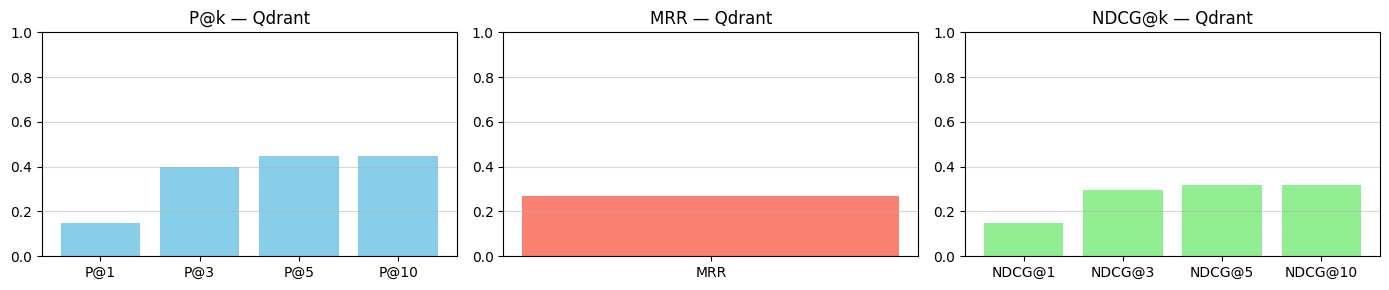

In [24]:
qdrant_metrics = evaluate_retriever(
    lambda q: qdrant_retriever.invoke(q), test_df, threshold=100
)
print_metrics(qdrant_metrics, "Qdrant")
results_summary["Qdrant"] = qdrant_metrics

#### Qdrant (семантический поиск)

100%|██████████| 20/20 [00:01<00:00, 10.35it/s]



=== Qdrant ===
P@k:   P@1=0.300  P@3=0.600  P@5=0.600  P@10=0.600
MRR:   0.442
NDCG:  NDCG@1=0.300  NDCG@3=0.483  NDCG@5=0.483  NDCG@10=0.483


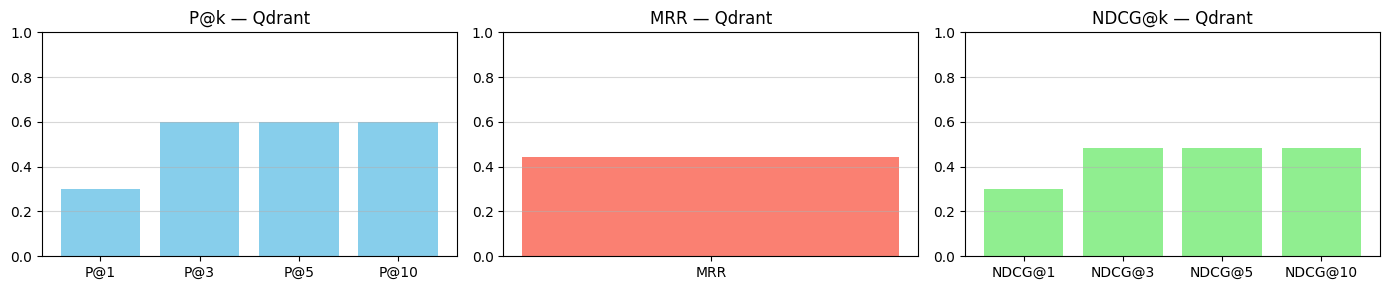

In [25]:
qdrant_metrics = evaluate_retriever(
    lambda q: qdrant_retriever.invoke(q), test_df
)
print_metrics(qdrant_metrics, "Qdrant")
results_summary["Qdrant"] = qdrant_metrics

#### Parent Document Retriever

100%|██████████| 20/20 [00:02<00:00,  9.32it/s]



=== Parent Document Retriever ===
P@k:   P@1=0.450  P@3=0.650  P@5=0.650  P@10=0.650
MRR:   0.550
NDCG:  NDCG@1=0.450  NDCG@3=0.576  NDCG@5=0.576  NDCG@10=0.576


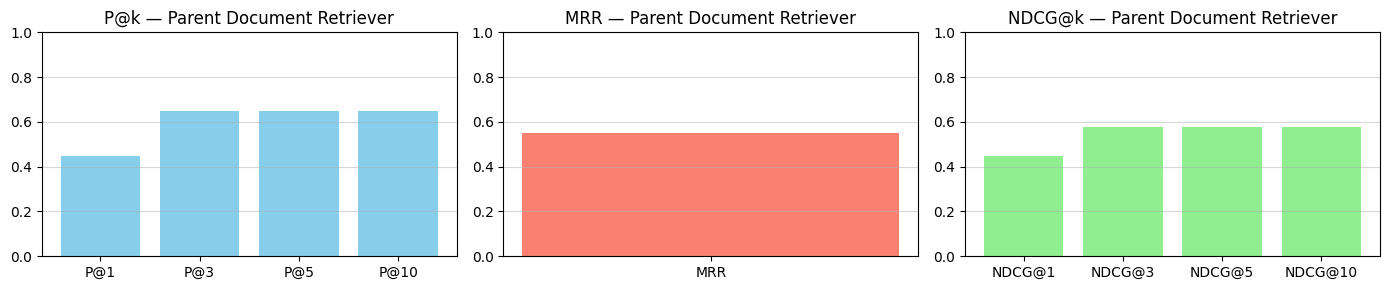

In [26]:
pd_metrics = evaluate_retriever(
    lambda q: pd_retriever.invoke(q), test_df
)
print_metrics(pd_metrics, "Parent Document Retriever")
results_summary["PD-Retriever"] = pd_metrics

In [27]:
! pip install rank_bm25

In [28]:
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

bm25_retriever = BM25Retriever.from_documents(doc_list)
bm25_retriever.k = 10

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, qdrant_retriever],
    weights=[0.5, 0.5],  # BM25 + Qdrant
)

/tmp/ipykernel_2834/3524154676.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.retrievers import BM25Retriever


#### BM25 (лексический поиск)

100%|██████████| 20/20 [00:00<00:00, 39.90it/s]



=== BM25 ===
P@k:   P@1=0.400  P@3=0.500  P@5=0.500  P@10=0.550
MRR:   0.438
NDCG:  NDCG@1=0.400  NDCG@3=0.450  NDCG@5=0.450  NDCG@10=0.464


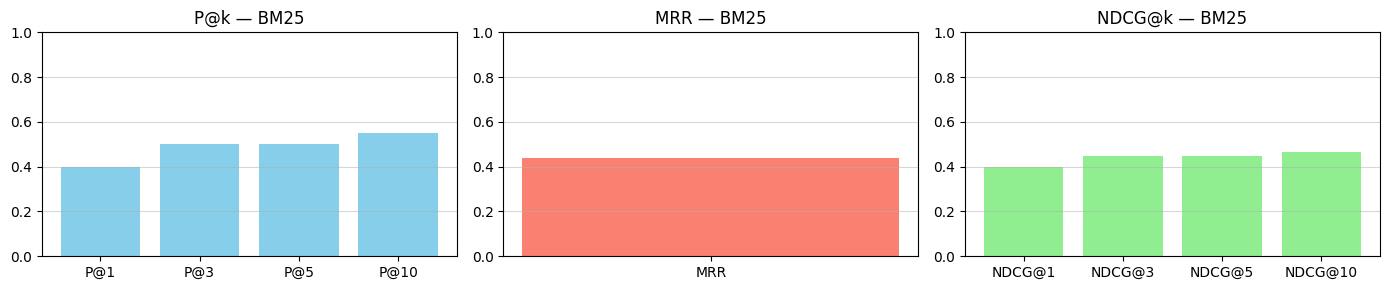

In [29]:
bm25_metrics = evaluate_retriever(
    lambda q: bm25_retriever.invoke(q), test_df
)
print_metrics(bm25_metrics, "BM25")
results_summary["BM25"] = bm25_metrics

#### Ensemble (BM25 + Qdrant)

100%|██████████| 20/20 [00:02<00:00,  7.24it/s]



=== Ensemble (BM25 + Qdrant) ===
P@k:   P@1=0.450  P@3=0.550  P@5=0.600  P@10=0.600
MRR:   0.502
NDCG:  NDCG@1=0.450  NDCG@3=0.507  NDCG@5=0.526  NDCG@10=0.526


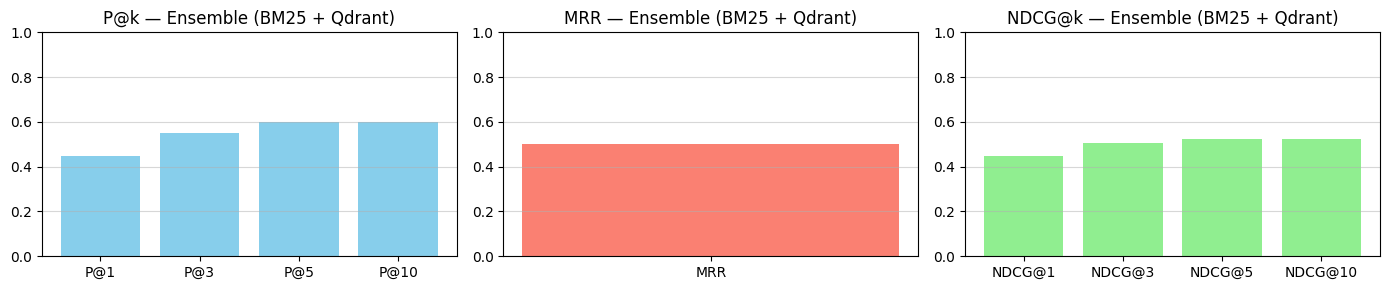

In [30]:
ensemble_metrics = evaluate_retriever(
    lambda q: ensemble_retriever.invoke(q), test_df
)
print_metrics(ensemble_metrics, "Ensemble (BM25 + Qdrant)")
results_summary["Ensemble"] = ensemble_metrics

**⭐⭐ Задание:** Функция `evaluate_retriever` предполагает ровно один правильный документ на вопрос. Добавь поддержку **нескольких релевантных документов** на один вопрос (NDCG с несколькими ненулевыми оценками). Что изменится в результатах?

## 3. Модификации RAG

### 3.1. Query Expansion

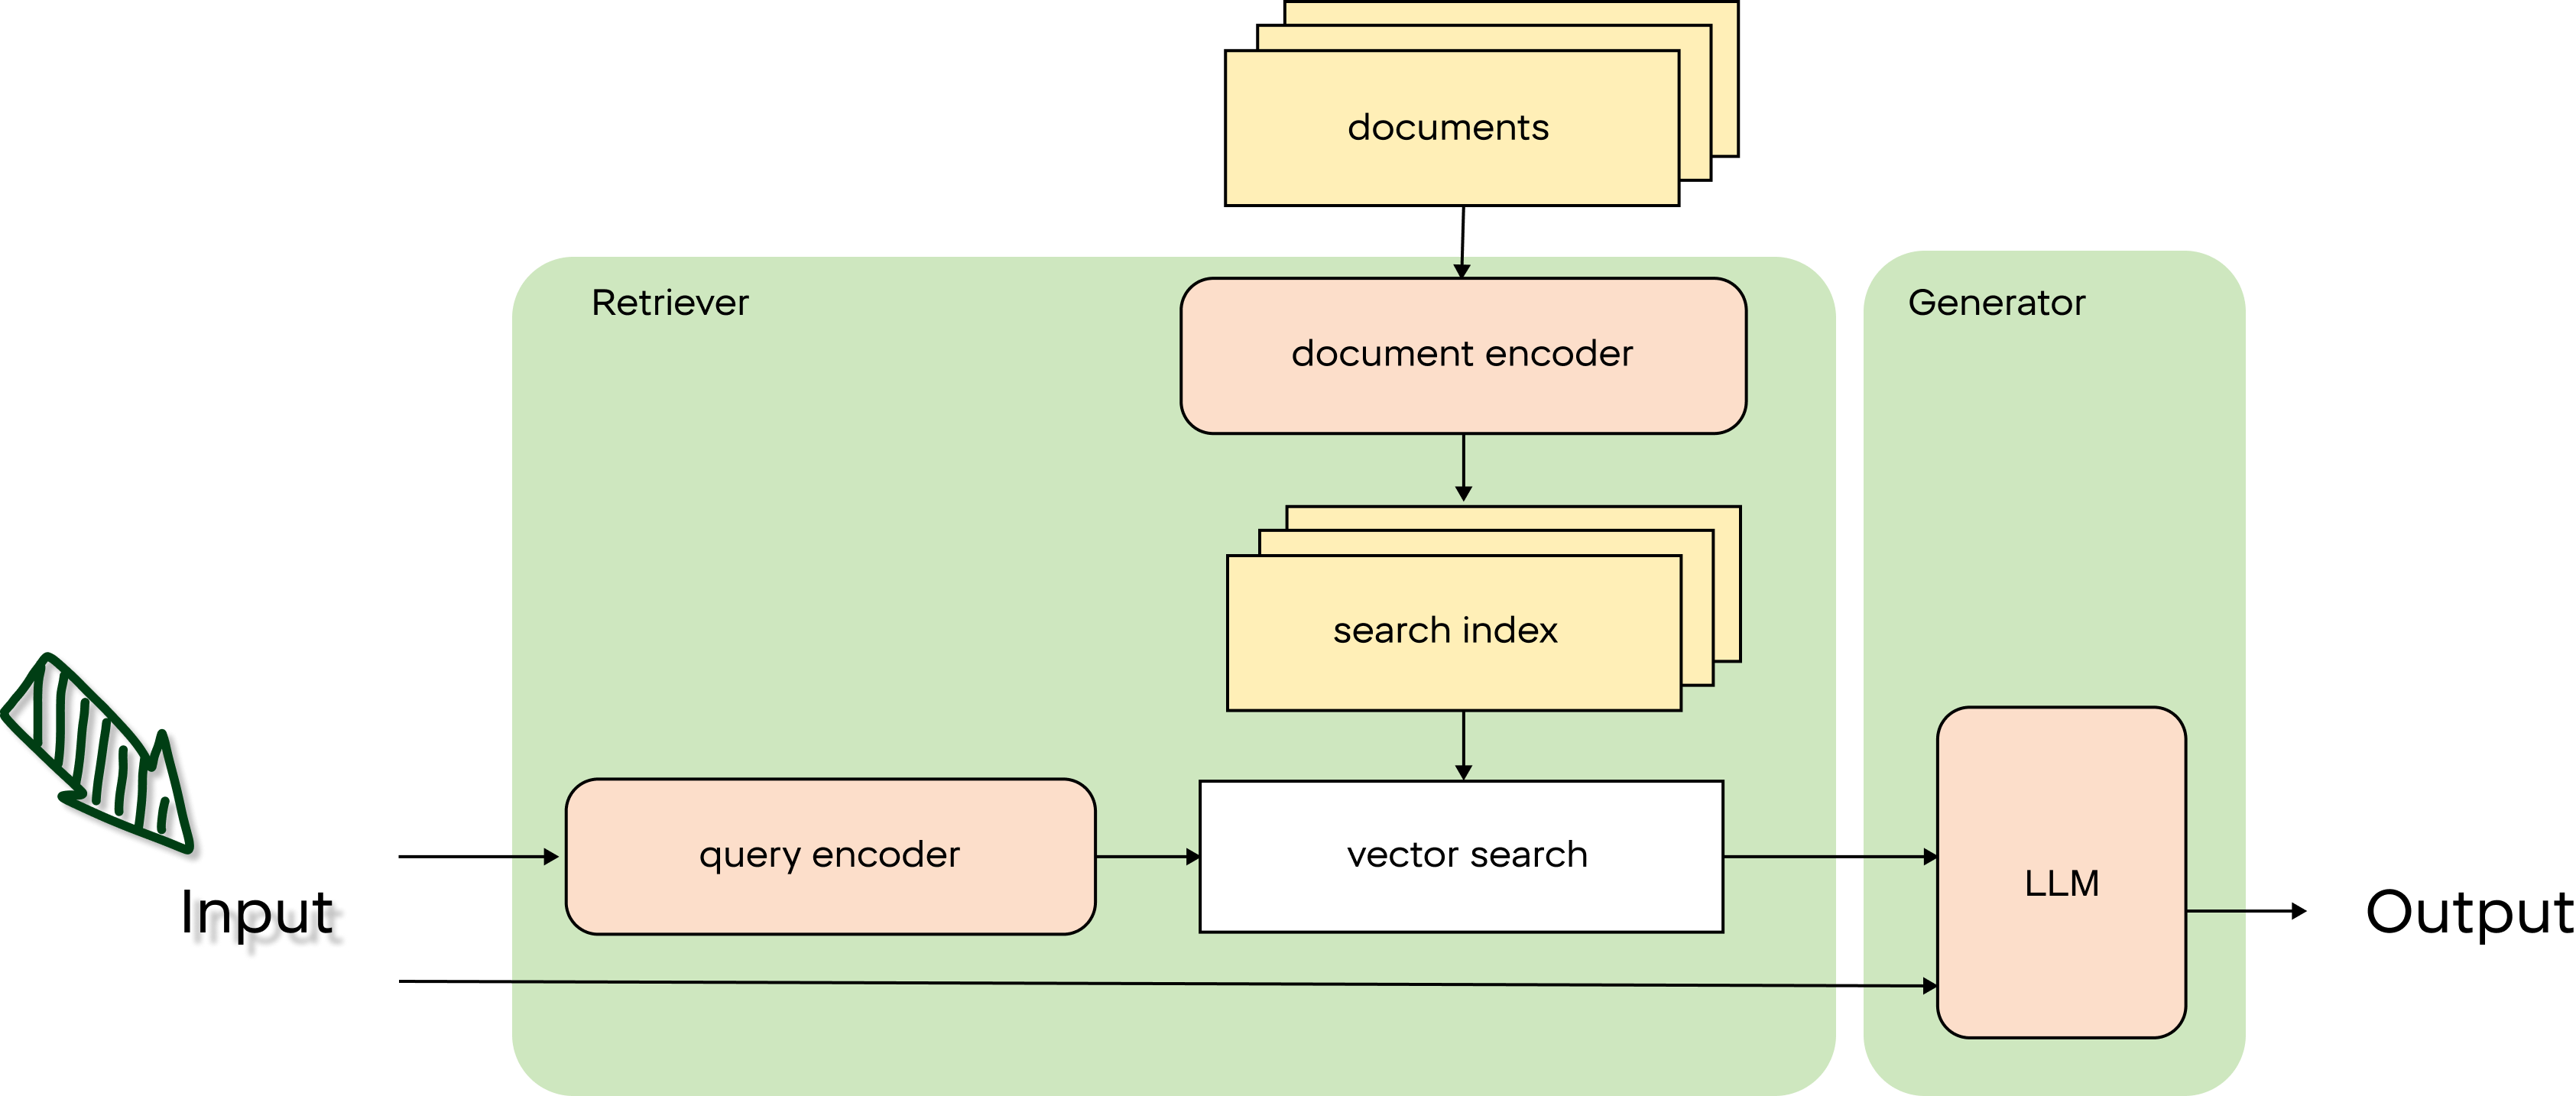

Часто случается так, что пользователи задают вопросы совсем не так, как мы ожидаем: с опечатками, неполно, неграмотно, и с этим нужно уметь работать (потому что у нас нет выбора).

Как правило, проблему с нестандартными, но полными запросами мы решаем перефразированием вопроса пользователя:

In [31]:
from transformers import pipeline
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

generation_pipeline = pipeline(
    "text-generation",
    model="RefalMachine/ruadapt_qwen2.5_3B_ext_u48_instruct_v4",
    device=device,
    dtype=torch.float16
)

cuda


config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/2.30M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/759 [00:00<?, ?B/s]

In [ ]:
# ованц -> аванс

In [ ]:
original = "чё делать если в промптах нерелевантная инфа?"
messages = [
    {"role": "system", "content": "Ты LLM-инженер и должен перефразировать вопросы пользователя, исправив грамматику, но не меняя смысл."},
    {"role": "user", "content": original},
]

paraphrased = generation_pipeline(messages, max_new_tokens=256, do_sample=True, temperature=0.5, top_p=0.9)[0]['generated_text'][-1]['content']
print(paraphrased)

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'temperature', 'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Что следует предпринять, если в промпте присутствуют ненужные или не относящие к теме данные?


#### Проверяем, улучшил ли Query Expansion качество поиска

  0%|          | 0/20 [00:00<?, ?it/s][transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
 50%|█████     | 10


=== Query Expansion + Qdrant ===
P@k:   P@1=0.350  P@3=0.550  P@5=0.600  P@10=0.600
MRR:   0.446
NDCG:  NDCG@1=0.350  NDCG@3=0.463  NDCG@5=0.485  NDCG@10=0.485


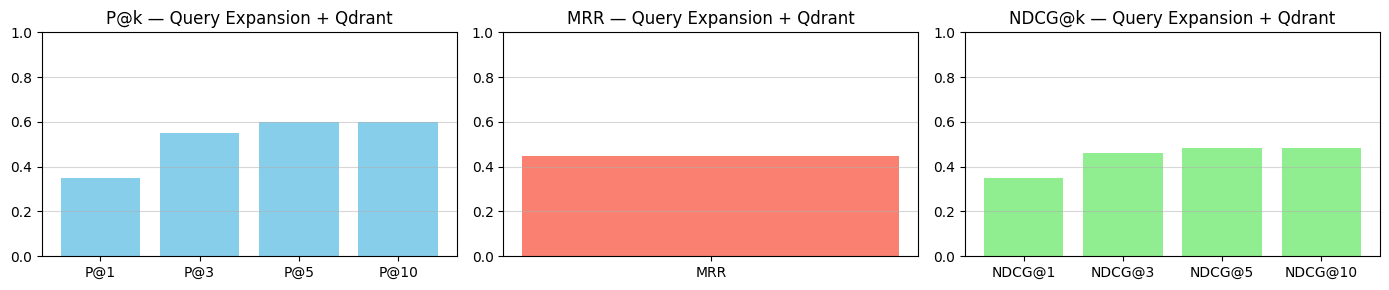

In [32]:
def qe_retriever_fn(question):
    """Перефразируем вопрос через LLM, затем ищем в Qdrant."""
    messages = [
        {'role': 'system', 'content': (
            'Ты LLM-инженер и должен перефразировать вопросы пользователя, '
            'исправив грамматику, но не меняя смысла. '
            'Отвечай только перефразированным вопросом, без пояснений.'
        )},
        {'role': 'user', 'content': question}
    ]
    expanded = (
        generation_pipeline(messages, max_new_tokens=64)
        [0]['generated_text'][-1]['content'].strip()
    )
    return qdrant_retriever.invoke(expanded)

qe_metrics = evaluate_retriever(qe_retriever_fn, test_df)
print_metrics(qe_metrics, "Query Expansion + Qdrant")
results_summary["QE + Qdrant"] = qe_metrics

**⭐ Задание:** Реализуй **Multi-Query**: сгенерируй N перефразировок вопроса, выполни поиск для каждой, объедини результаты (без дублей), верни топ-10. Сравни с одиночным QE по метрикам из `evaluate_retriever`.

### 3.2. HyDE — Hypothetical Document Embeddings

**Идея:** вместо того чтобы искать по запросу пользователя напрямую, попросим LLM сгенерировать *гипотетический ответ* — такой, как если бы он уже был в базе знаний. Эмбеддинг этого гипотетического документа используется как поисковый запрос.

**Контраст с QE:** QE исправляет *форму* вопроса (грамматику, стиль), HyDE угадывает *семантику ответа*. На коротких неполных вопросах HyDE обычно даёт больший прирост.

> Оригинальная статья: [Gao et al., 2022 — Precise Zero-Shot Dense Retrieval without Relevance Labels](https://arxiv.org/abs/2212.10496)

100%|██████████| 20/20 [01:15<00:00,  3.77s/it]



=== HyDE + Qdrant ===
P@k:   P@1=0.250  P@3=0.400  P@5=0.400  P@10=0.400
MRR:   0.308
NDCG:  NDCG@1=0.250  NDCG@3=0.332  NDCG@5=0.332  NDCG@10=0.332


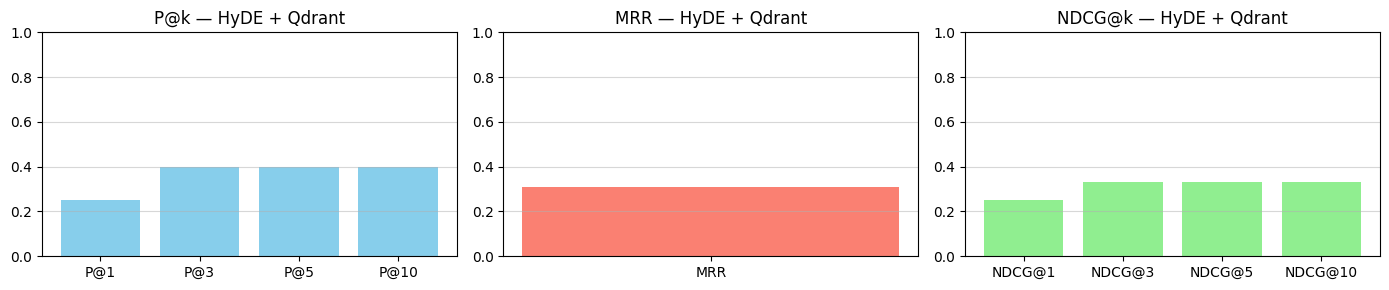

In [ ]:
def hyde_retriever_fn(question):
    """HyDE: генерируем гипотетический документ, ищем по его эмбеддингу."""
    messages = [
        {'role': 'system', 'content': (
            'Напиши короткий (2-3 предложения) гипотетический ответ на вопрос, '
            'как если бы он был фрагментом документа в базе знаний. '
            'Только текст ответа, без пояснений.'
        )},
        {'role': 'user', 'content': question}
    ]
    hypothetical_doc = (
        generation_pipeline(messages, max_new_tokens=128)
        [0]['generated_text'][-1]['content'].strip()
    )
    return qdrant_retriever.invoke(hypothetical_doc)

hyde_metrics = evaluate_retriever(hyde_retriever_fn, test_df)
print_metrics(hyde_metrics, "HyDE + Qdrant")
results_summary["HyDE + Qdrant"] = hyde_metrics

**⭐⭐ Задание:** Сравни HyDE и QE на одних и тех же вопросах из golden set. Для каких типов вопросов HyDE работает лучше? Для каких — хуже? Попробуй написать гибридную стратегию: сначала QE, затем HyDE, объединить результаты.

### 3.3. Reranking


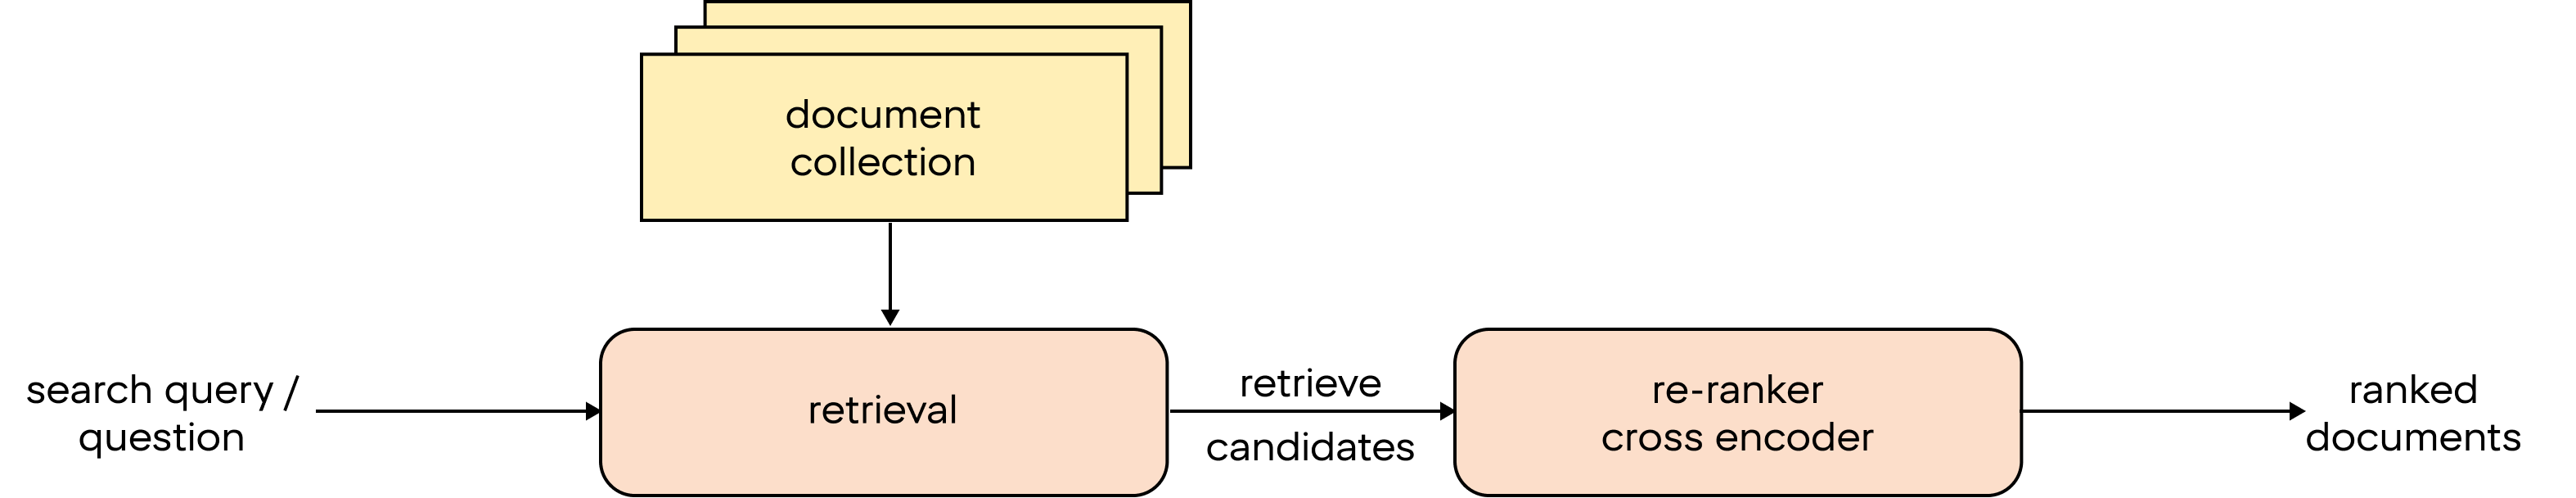

Reranker – это языковая модель, принимающая два текста и возвращающая близость между ними. В качестве реранкера мы будем использовать специальную мультиязычную модель, обученную для этих целей amberoad/bert-multilingual-passage-reranking-msmarco.

In [ ]:
#! pip install langchain_community

In [ ]:
from langchain_community.cross_encoders import HuggingFaceCrossEncoder

In [ ]:
cross_encoder = HuggingFaceCrossEncoder(
    model_name='BAAI/bge-reranker-v2-m3',
    model_kwargs={'device': device}
)
sum([p.numel() for p in cross_encoder.client.model.parameters()])

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

567755777

100%|██████████| 20/20 [01:15<00:00,  3.77s/it]



=== Ensemble + Reranking ===
P@k:   P@1=0.550  P@3=0.650  P@5=0.650  P@10=0.650
MRR:   0.600
NDCG:  NDCG@1=0.550  NDCG@3=0.613  NDCG@5=0.613  NDCG@10=0.613


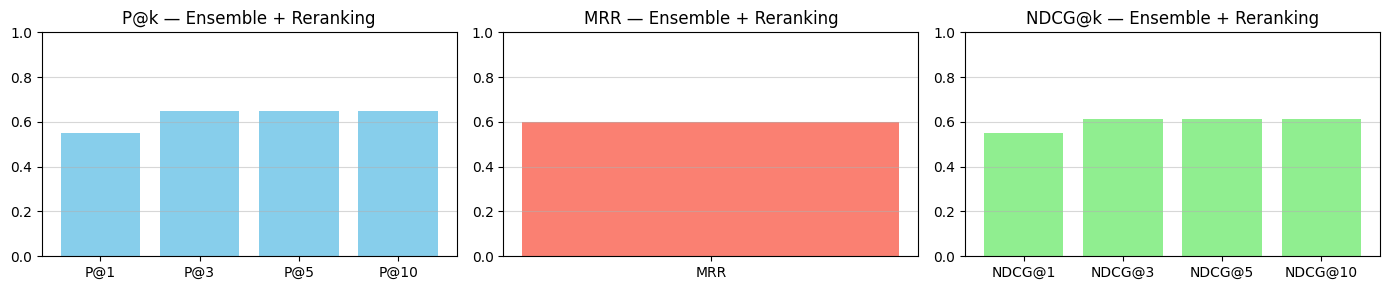

In [ ]:
def reranking_retriever_fn(question, k_candidates=20):
    """Ensemble → cross-encoder reranking → top-10."""
    candidates = ensemble_retriever.invoke(question)[:k_candidates]
    if not candidates:
        return []
    pairs  = [(question, doc.page_content) for doc in candidates]
    scores = cross_encoder.score(pairs)
    ranked = sorted(zip(scores, candidates), key=lambda x: x[0], reverse=True)
    return [doc for _, doc in ranked[:10]]

reranking_metrics = evaluate_retriever(reranking_retriever_fn, test_df)
print_metrics(reranking_metrics, "Ensemble + Reranking")
results_summary["Ensemble + Reranking"] = reranking_metrics

In [33]:
import gc

gc.collect()

7069

**⭐ Задание:** Поменяй `k_candidates` (число кандидатов для реранжирования): попробуй 20, 50, 100. При каком значении система начинает работать слишком медленно, а при каком — теряет в качестве?

### 3.4. CRAG — Corrective RAG

**Идея:** после получения кандидатов LLM оценивает их релевантность. Если контекст нерелевантен — система переключается на *fallback*-стратегию (веб-поиск, другой корпус или отказ от ответа). Это снижает риск галлюцинаций, когда ретривер возвращает «похожие, но не те» документы.

> Оригинальная статья: [Yan et al., 2024 — CRAG: Corrective Retrieval Augmented Generation](https://arxiv.org/abs/2401.15884)

В упрощённой реализации ниже используем тот же `generation_pipeline` для бинарной классификации релевантности.

100%|██████████| 20/20 [00:09<00:00,  2.21it/s]



=== CRAG (Qdrant + LLM-фильтр) ===
P@k:   P@1=0.250  P@3=0.500  P@5=0.500  P@10=0.500
MRR:   0.367
NDCG:  NDCG@1=0.250  NDCG@3=0.401  NDCG@5=0.401  NDCG@10=0.401


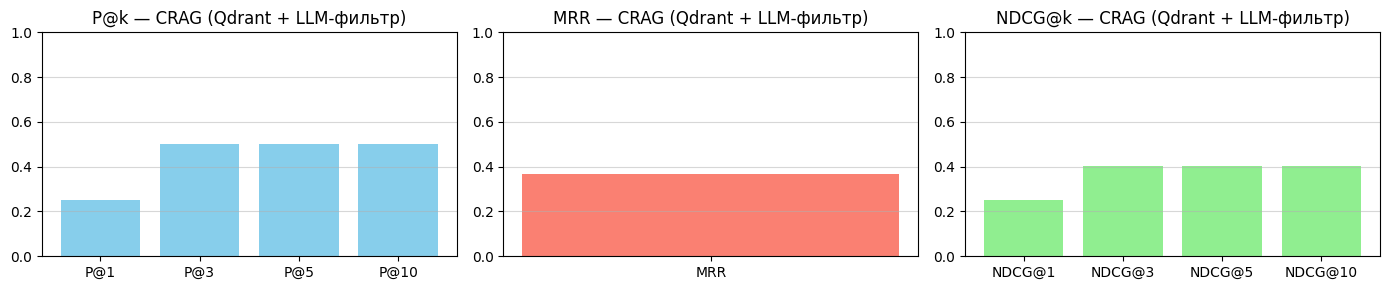

In [ ]:
def is_relevant_context(question, context):
    """Возвращает True, если LLM считает контекст релевантным."""
    messages = [
        {'role': 'system', 'content': (
            'Ты классификатор релевантности. '
            'Ответь ТОЛЬКО "yes" или "no": '
            'содержит ли контекст информацию, достаточную для ответа на вопрос?'
        )},
        {'role': 'user',
         'content': f'Вопрос: {question}\n\nКонтекст:\n{context}'}
    ]
    response = (
        generation_pipeline(messages, max_new_tokens=10)
        [0]['generated_text'][-1]['content'].strip().lower()
    )
    return 'yes' in response


def crag_retriever_fn(question):
    """CRAG: qdrant → проверка релевантности → fallback (пустой список)."""
    candidates = qdrant_retriever.invoke(question)
    if not candidates:
        return []
    if is_relevant_context(question, candidates[0].page_content):
        return candidates
    else:
        return []  # fallback: не знаю по данному корпусу

crag_metrics = evaluate_retriever(crag_retriever_fn, test_df)
print_metrics(crag_metrics, "CRAG (Qdrant + LLM-фильтр)")
results_summary["CRAG"] = crag_metrics

**⭐ Задание:** В текущей реализации порог бинарный: «yes» → принять, иначе → fallback. Поменяй промпт так, чтобы LLM возвращал **оценку от 1 до 5** (как в G-Eval), и экспериментируй с числовым порогом. При каком пороге система начинает слишком часто делать fallback и теряет покрытие?

---

## 4. Сводная таблица ретриверов

Все накопленные метрики — в одном месте.

In [ ]:
import pandas as pd

rows = []
for name, m in results_summary.items():
    row = {'Ретривер': name, 'MRR': round(m['MRR'], 3)}
    for k, v in m['P@k'].items():
        row[f'P@{k}'] = round(v, 3)
    for k, v in m['NDCG@k'].items():
        row[f'NDCG@{k}'] = round(v, 3)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Ретривер')
print(summary_df.to_string())
summary_df

                        MRR   P@1   P@3   P@5  P@10  NDCG@1  NDCG@3  NDCG@5  NDCG@10
Ретривер                                                                            
Qdrant                0.271  0.15  0.40  0.45  0.45    0.15   0.295   0.316    0.316
PD-Retriever          0.550  0.45  0.65  0.65  0.65    0.45   0.576   0.576    0.576
BM25                  0.438  0.40  0.50  0.50  0.55    0.40   0.450   0.450    0.464
Ensemble              0.502  0.45  0.55  0.60  0.60    0.45   0.507   0.526    0.526
QE + Qdrant           0.438  0.30  0.60  0.65  0.65    0.30   0.470   0.491    0.491
HyDE + Qdrant         0.308  0.25  0.40  0.40  0.40    0.25   0.332   0.332    0.332
Ensemble + Reranking  0.600  0.55  0.65  0.65  0.65    0.55   0.613   0.613    0.613
CRAG                  0.367  0.25  0.50  0.50  0.50    0.25   0.401   0.401    0.401


,MRR,P@1,P@3,P@5,P@10,NDCG@1,NDCG@3,NDCG@5,NDCG@10
Ретривер,,,,,,,,,
Qdrant,0.271,0.15,0.40,0.45,0.45,0.15,0.295,0.316,0.316
PD-Retriever,0.550,0.45,0.65,0.65,0.65,0.45,0.576,0.576,0.576
BM25,0.438,0.40,0.50,0.50,0.55,0.40,0.450,0.450,0.464
Ensemble,0.502,0.45,0.55,0.60,0.60,0.45,0.507,0.526,0.526
QE + Qdrant,0.438,0.30,0.60,0.65,0.65,0.30,0.470,0.491,0.491
HyDE + Qdrant,0.308,0.25,0.40,0.40,0.40,0.25,0.332,0.332,0.332
Ensemble + Reranking,0.600,0.55,0.65,0.65,0.65,0.55,0.613,0.613,0.613
CRAG,0.367,0.25,0.50,0.50,0.50,0.25,0.401,0.401,0.401


### Bonus: LLM-as-a-judge

До этого мы оценивали *ретривер* (находит ли нужный документ). Теперь оценим *качество ответа* — на выходе полного RAG-пайплайна.

Два критерия:
- **Relevance** (0–5): насколько ответ относится к вопросу
- **Faithfulness** (0–5): насколько ответ опирается на контекст (без галлюцинаций)

Требуем от модели строгий JSON — это *structured output*. Запускаем судью дважды (строгий и нестрогий промпт) и считаем **Cohen's Kappa κ** для оценки межсудейского согласия.

In [ ]:
import json, re
from sklearn.metrics import cohen_kappa_score


def llm_judge(question, context, answer, strict=False):
    """
    Оценивает ответ по relevance и faithfulness (0-5 каждый).
    strict=True -> более строгие критерии (второй судья).
    Возвращает dict {'relevance': int, 'faithfulness': int}.
    """
    strictness = (
        ' Будь строг: снижай оценку даже за незначительные отклонения.'
        if strict else ''
    )
    prompt = (
        f'Оцени качество ответа на вопрос.{strictness}\n\n'
        f'Вопрос: {question}\n'
        f'Контекст: {context}\n'
        f'Ответ: {answer}\n\n'
        'Верни JSON строго в таком формате (только JSON, без пояснений):\n'
        '{"relevance": <число 0-5>, "faithfulness": <число 0-5>}'
    )
    raw = (
        generation_pipeline([{'role': 'user', 'content': prompt}], max_new_tokens=64)
        [0]['generated_text'][-1]['content'].strip()
    )
    try:
        m = re.search(r'\{[^}]+\}', raw)
        if m:
            s = json.loads(m.group())
            return {'relevance':    int(s.get('relevance',    -1)),
                    'faithfulness': int(s.get('faithfulness', -1))}
    except (json.JSONDecodeError, ValueError, KeyError):
        pass
    return {'relevance': -1, 'faithfulness': -1}


demo_questions = test_df['question'].tolist()[:5]
demo_contexts  = test_df['text'].tolist()[:5]

j1_rel, j2_rel, j1_fai, j2_fai = [], [], [], []

for q, ctx in zip(demo_questions, demo_contexts):
    ans = (
        generation_pipeline(
            [{'role': 'user', 'content': f'Контекст:\n{ctx}\n\nВопрос: {q}\n\nОтвет:'}],
            max_new_tokens=128
        )[0]['generated_text'][-1]['content'].strip()
    )
    s1 = llm_judge(q, ctx, ans, strict=False)
    s2 = llm_judge(q, ctx, ans, strict=True)
    j1_rel.append(s1['relevance']);   j2_rel.append(s2['relevance'])
    j1_fai.append(s1['faithfulness']); j2_fai.append(s2['faithfulness'])
    print(f'Q: {q[:60]}...')
    print(f'  Судья-1: relevance={s1["relevance"]}, faithfulness={s1["faithfulness"]}')
    print(f'  Судья-2: relevance={s2["relevance"]}, faithfulness={s2["faithfulness"]}')
    print()

[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/do

Q: Почему авторы считают, что попытка сохранить весь контекст в...
  Судья-1: relevance=4, faithfulness=3
  Судья-2: relevance=3, faithfulness=4



[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Как устроен механизм Log-Linear Attention и за счет чего он ...
  Судья-1: relevance=4, faithfulness=3
  Судья-2: relevance=4, faithfulness=3



[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Как показал себя Log-Linear Attention по сравнению с обычным...
  Судья-1: relevance=3, faithfulness=4
  Судья-2: relevance=3, faithfulness=3



[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: В чем заключается основная идея сетей Колмогорова-Арнольда (...
  Судья-1: relevance=4, faithfulness=3
  Судья-2: relevance=2, faithfulness=1



[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Как связаны теоремы Цыбенко и Колмогорова-Арнольда с архитек...
  Судья-1: relevance=4, faithfulness=3
  Судья-2: relevance=2, faithfulness=1



####Коэффициент Коэна κ (Cohen’s Kappa)


**Коэффициент Коэна κ** — мера согласия **двух аннотаторов** (или двух «судей») при категоризации объектов, **скорректированная на случайное совпадение**.

* Пусть есть два набора меток для N объектов: (A) и (B).
* (p_o) — наблюдаемая доля совпадений (accuracy).
* (p_e) — ожидаемая доля совпадений «по случаю» (исходя из частот классов у каждого аннотатора).

Тогда:
$$
\kappa ;=; \frac{p_o - p_e}{1 - p_e}.
$$

* Если (\kappa = 1): полное согласие (лучше не бывает).
* Если (\kappa = 0): согласие не лучше случайного.
* Если (\kappa < 0): хуже случайного — систематическое расхождение.

**Интерпретация (популярная шкала Landis & Koch, условная!)**

* **< 0.00** — плохое
* **0.00–0.20** — слабое
* **0.21–0.40** — удовлетворительное
* **0.41–0.60** — умеренное
* **0.61–0.80** — существенное
* **0.81–1.00** — почти идеальное

> Важно: κ чувствителен к **дисбалансу классов** и **смещению порогов**. Если один аннотатор чаще ставит «релевантно», чем другой, κ может снижаться, даже при высокой точности.


In [ ]:
def clamp(scores, lo=0, hi=5):
    return [max(lo, min(hi, s)) for s in scores]

kappa_rel = cohen_kappa_score(clamp(j1_rel), clamp(j2_rel))
kappa_fai = cohen_kappa_score(clamp(j1_fai), clamp(j2_fai))

print(f"Cohen's κ (relevance):    {kappa_rel:.3f}")
print(f"Cohen's κ (faithfulness): {kappa_fai:.3f}")
print()
print('Интерпретация:')
for lo, hi, label in [(.0,.2,'слабое'), (.2,.4,'удовлетворительное'),
                       (.4,.6,'умеренное'), (.6,.8,'существенное'), (.8,1.,'почти идеальное')]:
    print(f'  {lo:.1f}–{hi:.1f}: {label}')

Cohen's κ (relevance):    0.211
Cohen's κ (faithfulness): -0.250

Интерпретация:
  0.0–0.2: слабое
  0.2–0.4: удовлетворительное
  0.4–0.6: умеренное
  0.6–0.8: существенное
  0.8–1.0: почти идеальное


#### Другие советы:

* Для LLM-судьи ставьте **temperature=0** и требуйте **строгий JSON** — меньше дрейфа.
* Снижайте стоимость: сначала **retrieval → rerank (cross-encoder)**, и уже **на top-10** зовите LLM-judge.

**⭐⭐ Задание:** Добавь третий критерий оценки — **`conciseness`** (насколько ответ краткий и по делу, 0–5). Пересчитай Cohen's Kappa для всех трёх критериев. Как изменилось межсудейское согласие?

### Быстрый чек-лист по базовым RAG техникам и их выбору:

1. Есть ли внешние документы, от которых зависит правильность ответа?
    * Да; Объём документов больше контекстного окна модели?
        * Да → нужен RAG, ретривер/чанкирование.
        * Нет → можно попытаться засунуть все документы в системный промпт.
    * Нет; Не используем контексты при генерации
2. Запрос короткий и отличается от формулировок в документах?
    * Да, несильно → подумай о различных энкодерах, query expansion, reranker.
    * Да, сильно → скорее всего стоит использовать симметричный поиск вместо асимметричного
3. Нужно цитирование / трассируемость?
    * Да → делай RAG (с сохранением источников).
4. Домены с высокой ценой ошибки?
    * Да → RAG + строгая инструкция «опираться только на контекст».

А что если пользователи могут задавать оба вида вопросов, и мы хотим уметь отвечать на оба? Да давайте просто всё в RAG засунем...

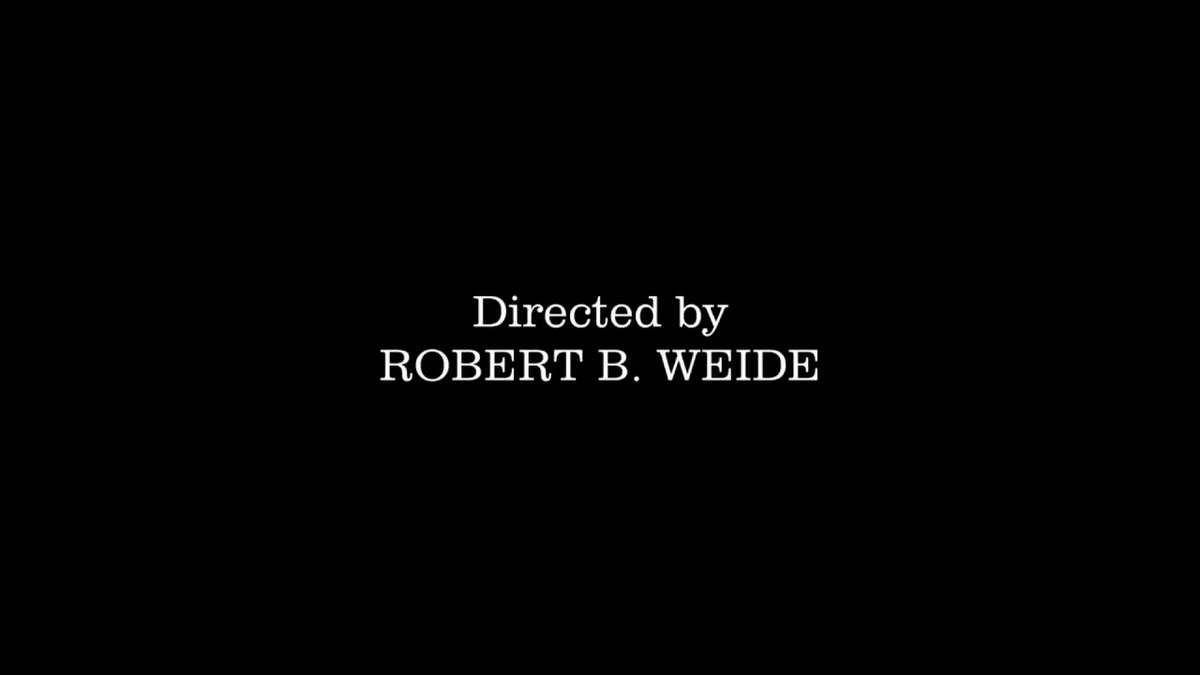

Call me maybe!! tg: @xufana / @al_potekhin

---

### Bonus: RAG-модуль на LangChain (LCEL)

До этого мы собирали кусочки RAG-пайплайна руками: отдельно ретривер, отдельно генерация через `transformers.pipeline`. На практике эти кусочки удобно объединять в единый **RAG-модуль** при помощи **LangChain Expression Language (LCEL)** — декларативного способа собирать цепочки вида `retriever -> prompt -> llm -> parser` оператором `|`.

Сборка из четырёх частей:
1. **Retriever** — `qdrant_retriever`, `bm25_retriever`, `ensemble_retriever`.
2. **Форматирование контекста** — список `Document` → один текстовый блок.
3. **Prompt template** — шаблон с `{context}` и `{question}`.
4. **LLM** — любая LangChain-совместимая обёртка. Ниже `ChatOpenAI` как заглушка; в реальном пайплайне — `HuggingFacePipeline(pipeline=generation_pipeline)` (та модель, что запускалась в разделе QE).

In [ ]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

rag_prompt = ChatPromptTemplate.from_template(
    'Ты — ассистент, отвечающий на вопросы по контексту ниже.\n'
    'Если в контексте нет ответа, явно скажи об этом.\n\n'
    'Контекст:\n{context}\n\nВопрос: {question}\n\nОтвет:'
)

def format_docs(docs):
    return '\n\n'.join(doc.page_content for doc in docs)

# Заглушка — замени на HuggingFacePipeline(pipeline=generation_pipeline)
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

rag_chain = (
    {'context': qdrant_retriever | format_docs, 'question': RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

question = 'Как быть, если в промптах для LLM содержится нерелевантная информация?'
print(rag_chain.invoke(question))

### Bonus: тот же RAG-модуль на локальной модели (`HuggingFacePipeline`)

Чтобы использовать `generation_pipeline` вместо `ChatOpenAI`, оборачиваем её в `HuggingFacePipeline`. Ключевое отличие: `transformers.pipeline` ожидает **строку**, а не список сообщений, поэтому промпт строим через `PromptTemplate`, а не `ChatPromptTemplate`.

In [ ]:
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate

local_llm = HuggingFacePipeline(pipeline=generation_pipeline)

rag_prompt_local = PromptTemplate.from_template(
    'Ты — ассистент, отвечающий на вопросы по контексту ниже.\n'
    'Если в контексте нет ответа, явно скажи об этом.\n\n'
    'Контекст:\n{context}\n\nВопрос: {question}\n\nОтвет:'
)

rag_chain_local = (
    {'context': qdrant_retriever | format_docs, 'question': RunnablePassthrough()}
    | rag_prompt_local
    | local_llm
    | StrOutputParser()
)

question = 'Как быть, если в промптах для LLM содержится нерелевантная информация?'
print(rag_chain_local.invoke(question))

---

## Литература и ссылки

**RAG & Ретриверы:**
- [Lewis et al., 2020 — RAG for Knowledge-Intensive NLP Tasks](https://arxiv.org/abs/2005.11401)
- [Robertson & Zaragoza, 2009 — BM25 and Beyond](https://dl.acm.org/doi/10.1561/1500000019)

**Advanced RAG:**
- [Gao et al., 2022 — HyDE: Precise Zero-Shot Dense Retrieval](https://arxiv.org/abs/2212.10496)
- [Yan et al., 2024 — CRAG: Corrective Retrieval Augmented Generation](https://arxiv.org/abs/2401.15884)

**LLM-as-a-Judge & Evaluation:**
- [Zheng et al., 2023 — MT-Bench and Chatbot Arena](https://arxiv.org/abs/2306.05685)
- [Liu et al., 2023 — G-Eval: NLG Evaluation using GPT-4](https://arxiv.org/abs/2303.16634)
- [Es et al., 2023 — RAGAS: Automated Evaluation of RAG](https://arxiv.org/abs/2309.15217)

**Embeddings:**
- [Chen et al., 2024 — BGE M3-Embedding](https://arxiv.org/abs/2402.03216)
- [MTEB Russian Leaderboard](https://huggingface.co/spaces/mteb/leaderboard?language=rus)

**Инструменты:**
- [LangChain LCEL](https://python.langchain.com/docs/expression_language/)
- [Qdrant Docs](https://qdrant.tech/documentation/)
- [RAGAS Framework](https://docs.ragas.io/)